In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [3]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/DataSets/waste.csv')  # change path if needed

df.head()

Mounted at /content/drive


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


###**Hadnling Missing Data**
Missing values can effect training. We fill them using forward fill

In [4]:
data=df.fillna(method='ffill')

/tmp/ipykernel_10092/2815386619.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data=df.fillna(method='ffill')


In [5]:
#Extract Feature to predict
#we only use the waste column for forecast
waste_data=data[['waste_volume']]

###**Normalize the Data**
Neural networks work better when the data values are scaled between 0 and 1


In [6]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)

###**Conver Data into Sequence**
RNN requires sequential input
Example:
Previous 10 days -> Predict next day

In [7]:
def create_sequence(data,seq_length):
  X=[]
  Y=[]
  for i in range(len(data)-seq_length):
    X.append(data[i:i+seq_length])
    Y.append(data[i+seq_length])
  return np.array(X),np.array(Y)

##**Create Time Sequences**

In [8]:
sequence_length=10
X,y=create_sequence(scaled_data,sequence_length)
print(X.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


#

###**BUILD THE RNN MODEL**
Architecture:

Input -> RNN Layer -> Dense Output


In [9]:

model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


####**Complie the Model**


In [10]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
split=int(0.8*len(X))

X_train=X[:split]
y_train=y[:split]

X_test=X[split:]
y_test=y[split:]

In [15]:
history=model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test,y_test)
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0095 - val_loss: 0.0095
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0095 - val_loss: 0.0093
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0098 - val_loss: 0.0095
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - val_loss: 0.0092
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0096 - val_loss: 0.0097
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0095 - val_loss: 0.0094
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0095 - val_loss: 0.0095
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0097
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_lo

###**Evaluate the model**

In [16]:
loss=model.evaluate(X_test,y_test)
print("Test Loss:",loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097  
Test Loss: 0.00968768261373043


####**Make Predictions**


In [17]:
predictions=model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


####**Convert Predictions Back to Original Scale**



In [18]:
prediction=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test)

###**Plot Predictions vs Actual Values**

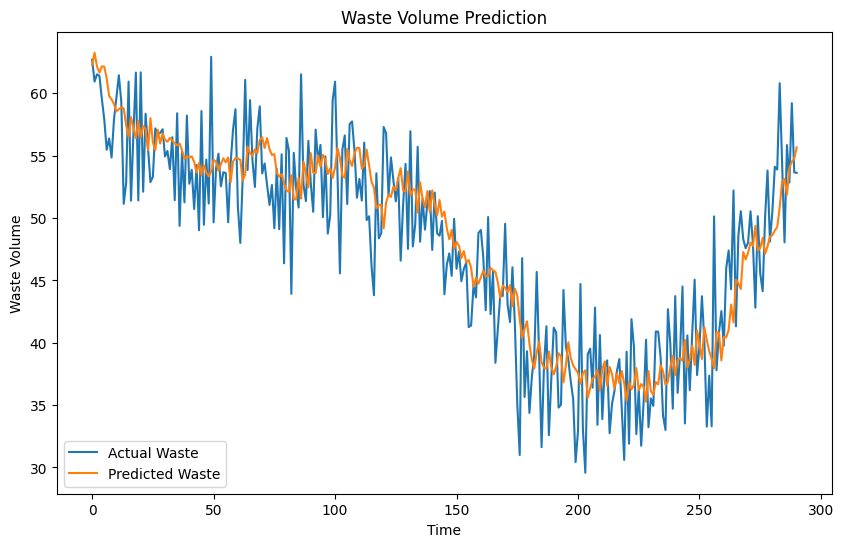

In [21]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual,label='Actual Waste')
plt.plot(prediction,label='Predicted Waste')

plt.title("Waste Volume Prediction")
plt.xlabel("Time")
plt.ylabel("Waste Volume")
plt.legend()
plt.show()